Реалізуйте web-скрапінг будь-яких платформ / виробників з продажу автомобілів.
Бажано обробити не менше 3-х джерел.
Проведіть агрегацію пропозицій за категоріями: 'позашляховики', 'седани', 'мінівени'.
Результати збережіть у файлах.

Провести порівняльний аналіз пропозицій між платформами з використанням штучних нейронних мереж

In [92]:
from bs4 import BeautifulSoup
import requests
import re
from deep_translator import GoogleTranslator
from nltk.tokenize import RegexpTokenizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os.path
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.decomposition import PCA
import stanza
import numpy as np
import random
import warnings

In [52]:
from scipy.spatial import distance
from sentence_transformers import SentenceTransformer
model_minilm = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [53]:
import tensorflow as tf
import tensorflow_hub as hub
module_url = "https://tfhub.dev/google/universal-sentence-encoder/4"
model_use = hub.load(module_url)

In [54]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('GPU not found — CPU is being used')

Device: cpu
GPU not found — CPU is being used


In [55]:
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F
tokenizer_e5 = AutoTokenizer.from_pretrained('intfloat/multilingual-e5-base')
model_e5 = AutoModel.from_pretrained('intfloat/multilingual-e5-base')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [81]:
name_minilm = 'all-MiniLM-L6-v2'
name_use = 'universal-sentence-encoder'
name_e5 = 'multilingual-e5-base'

In [56]:
warnings.filterwarnings(action='ignore')

In [57]:
nlp = stanza.Pipeline('uk', processors='tokenize,mwt,pos,lemma')
selected_pos = ['ADP', 'PART', 'DET', 'SCONJ', 'CCONJ']

INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: uk (Ukrainian):
| Processor | Package     |
---------------------------
| tokenize  | iu          |
| mwt       | iu          |
| pos       | iu_charlm   |
| lemma     | iu_nocharlm |

INFO:stanza:Using device: cpu
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Done loading processors!


In [58]:
PROJECT_PATH = 'D:\\uni\\3курс\\NLP\\NLP_labs\lab6'
CSV_NAME = 'lab6.csv'
CSV_PATH = os.path.join(PROJECT_PATH, CSV_NAME)

RAW_FILENAME = 'raw_text.csv'
CLEANED_FILENAME = 'cleaned_text.csv'

In [59]:
NAME_OLX = 'Olx'
NAME_AUTORIA = 'AutoRIA'
NAME_AUTOMOTO = 'AUTOMOTO'

AUTO_TYPES = {0: 'позашляховики', 1: 'седани', 2: 'мінівени'}

In [60]:
URLS = {NAME_OLX: ['https://www.olx.ua/uk/transport/legkovye-avtomobili/?currency=UAH&search%5Bfilter_enum_car_body%5D%5B0%5D=off-road-vehicle',
                   'https://www.olx.ua/uk/transport/legkovye-avtomobili/?currency=UAH&search%5Bfilter_enum_car_body%5D%5B0%5D=sedan',
                   'https://www.olx.ua/uk/transport/legkovye-avtomobili/?currency=UAH&search%5Bfilter_enum_car_body%5D%5B0%5D=minibus'],
        NAME_AUTORIA: ['https://auto.ria.com/uk/search/?search_type=1&category=1&bodystyle[0]=5&abroad=0&customs_cleared=1&page=0&limit=20',
                       'https://auto.ria.com/uk/search/?search_type=1&category=1&bodystyle[0]=3&abroad=0&customs_cleared=1&page=0&limit=20',
                       'https://auto.ria.com/uk/search/?search_type=1&category=1&bodystyle[0]=8&abroad=0&customs_cleared=1&page=0&limit=20'],
        NAME_AUTOMOTO: ['https://automoto.ua/uk/car/Vnedorozhnik-Krossover',
                        'https://automoto.ua/uk/car/Sedan',
                        'https://automoto.ua/uk/car/Miniven']}

In [61]:
def view_site(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'lxml')
    print(soup)
    return

In [62]:
def news_parser(url, name, filename):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'lxml')

    if name == NAME_OLX:
        # h4 css-wlcw7o
        quotes = soup.find_all('h4', class_='css-wlcw7o')
    elif name == NAME_AUTORIA:
        quotes = soup.find_all('div', class_='titleS')
    else:
        quotes = soup.find_all('div', class_='card-name')

    # to pandas df
    data = pd.DataFrame(columns=['Title'])
    for quote in quotes:
        data.loc[len(data)] = quote.text
    data.to_csv(filename, index=True)
    #print(data)
    #print()
    return

In [63]:
def clean_text(text):
    def lemmatize_and_stuff(text):
        doc = nlp(text)
        lemmas = [word.lemma for t in doc.iter_tokens() for word in t.words]
        pos = [word.upos for t in doc.iter_tokens() for word in t.words]
        tokens_data = pd.DataFrame(
            {
                'Word': lemmas,
                'POS': pos
            }
        )
        tokens_data.drop(tokens_data[tokens_data['POS'].isin(selected_pos)].index, inplace=True)

        return " ".join(tokens_data['Word'])

    def rus_to_uk(text):
        translation = GoogleTranslator(source="russian", target="ukrainian").translate(text)
        return translation

    # переклад з рос на українську
    text = rus_to_uk(text)

    # посилання
    text = re.sub(r"https?://\S+|www\.\S+", '', text)
    # html теги
    text = re.sub(r"<.*?>", '', text)
    # пунктуація
    text = re.sub(r"[^\w\s]", ' ', text)
    # слова з цифрами
    text = re.sub(r"\w*\d\w*", '', text)
    # цифри
    text = re.sub(r'\d+', '', text)
    #
    text = re.sub(r' ', ' ', text)

    text = lemmatize_and_stuff(text)
    # пунктуація (ще раз)
    text = re.sub(r"[^\w\s]", ' ', text)

    # extra spaces
    text = " ".join(text.split())

    return text.lower()

In [103]:
def similarity_analysis(data, N=range(10, 21, 5)):
    labels = list(data.keys())

    def plot_kde(emb1, emb2, name1, name2, title=''):
        sim_11 = cosine_similarity(emb1)
        sim_11_vals = sim_11[np.triu_indices_from(sim_11, k=1)]
        sim_22 = cosine_similarity(emb2)
        sim_22_vals = sim_22[np.triu_indices_from(sim_22, k=1)]

        sim_12 = cosine_similarity(emb1, emb2)
        sim_12_vals = sim_12.flatten()

        sns.kdeplot(sim_11_vals, fill=True, alpha=0.4, label=f'{name1}')
        sns.kdeplot(sim_22_vals, fill=True, alpha=0.4, label=f'{name2}')
        sns.kdeplot(sim_12_vals, fill=False, color='black', linestyle="--", linewidth=2, label=f'{name1} vs {name2}')

        plt.title(f'KDE of {name1} and {name2} ' + title)
        plt.xlabel('cosine similarity')
        plt.ylabel('KDE')
        plt.grid(True, alpha=0.4)
        plt.legend()
        plt.show()

    def plot_text_heatmap(df, title=''):
        plt.figure(figsize=(12, 5))
        sns.heatmap(df, xticklabels=labels, yticklabels=labels, fmt='.4f', annot=True, cmap="rocket")
        plt.title(f'Heatmap '+title)
        plt.show()

    def get_centroid(emb):
      centroid = np.mean(emb, axis=0, keepdims=True)
      return centroid / np.linalg.norm(centroid)

    def embedding_e5(text, batch_size=32):
      embeddings = []
      for i in range(0, len(text), batch_size):
            batch_text = text[i:i+batch_size]
            batch_dict = tokenizer_e5(batch_text, max_length=512, padding=True, truncation=True, return_tensors='pt')

            with torch.no_grad():
                outputs = model_e5(**batch_dict)

            attention_mask = batch_dict['attention_mask']
            last_hidden = outputs.last_hidden_state.masked_fill(~attention_mask[..., None].bool(), 0.0)
            pooled = last_hidden.sum(dim=1) / attention_mask.sum(dim=1)[..., None]
            pooled = F.normalize(pooled, p=2, dim=1)

            embeddings.append(pooled.cpu().numpy())

      return np.vstack(embeddings)


    ######## MINILM
    print()
    print(name_minilm)

    centroids_minilm = []
    for name in labels:
        text = data[name]
        embs = model_minilm.encode(text)
        centroids_minilm.append(get_centroid(embs)[0])

    cos_similarity = cosine_similarity(centroids_minilm)
    plot_text_heatmap(cos_similarity, name_minilm)

    embeddings_for_kde = []
    for _, arr in data.items():
        embeddings_for_kde.append(model_minilm.encode(arr))

    plot_kde(embeddings_for_kde[0], embeddings_for_kde[1], AUTO_TYPES[0], AUTO_TYPES[1], name_minilm)
    plot_kde(embeddings_for_kde[0], embeddings_for_kde[2], AUTO_TYPES[0], AUTO_TYPES[2], name_minilm)
    plot_kde(embeddings_for_kde[1], embeddings_for_kde[2], AUTO_TYPES[1], AUTO_TYPES[2], name_minilm)


    ####### USE
    print()
    print(name_use)

    centroids_use = []
    for name in labels:
        text = data[name]
        embs = model_use(text).numpy()
        centroids_use.append(get_centroid(embs)[0])

    cos_similarity = cosine_similarity(centroids_use)
    plot_text_heatmap(cos_similarity, name_use)

    embeddings_for_kde = []
    for _, arr in data.items():
        embeddings_for_kde.append(model_use(arr).numpy())

    plot_kde(embeddings_for_kde[0], embeddings_for_kde[1], AUTO_TYPES[0], AUTO_TYPES[1], name_use)
    plot_kde(embeddings_for_kde[0], embeddings_for_kde[2], AUTO_TYPES[0], AUTO_TYPES[2], name_use)
    plot_kde(embeddings_for_kde[1], embeddings_for_kde[2], AUTO_TYPES[1], AUTO_TYPES[2], name_use)

    ####### e5 torch
    print()
    print(name_e5)
    prefix = 'query: '
    batch_size=32

    centroids_e5 = []
    for name in labels:
        text = [prefix + t for t in data[name]]
        embeddings = embedding_e5(text, batch_size)
        centroids_e5.append(get_centroid(embeddings)[0])

    cos_similarity = cosine_similarity(centroids_e5)
    plot_text_heatmap(cos_similarity, name_e5)

    embeddings_for_kde = []
    for name, arr in data.items():
        text = [prefix + t for t in data[name]]
        embeddings_for_kde.append(embedding_e5(text, batch_size))

    plot_kde(embeddings_for_kde[0], embeddings_for_kde[1], AUTO_TYPES[0], AUTO_TYPES[1], name_e5)
    plot_kde(embeddings_for_kde[0], embeddings_for_kde[2], AUTO_TYPES[0], AUTO_TYPES[2], name_e5)
    plot_kde(embeddings_for_kde[1], embeddings_for_kde[2], AUTO_TYPES[1], AUTO_TYPES[2], name_e5)

    return

Section for calling functions

In [65]:
flag = False
for name in URLS.keys():
    curr_folder = os.path.join(PROJECT_PATH, name)
    if os.path.exists(curr_folder):
        flag = True
        break

In [66]:
if not flag:
    for name, urls in URLS.items():
        print(f'PARSING {name}...')
        curr_folder = os.path.join(PROJECT_PATH, name)
        os.makedirs(curr_folder)
        for i in range(3):
            file = os.path.join(curr_folder, name+'_'+str(i)+'.csv')
            news_parser(urls[i], name, file)
        print()
        print('MAKING A DATAFRAME')
    start_idx = 0
    df = pd.read_csv(os.path.join(os.path.join(PROJECT_PATH, NAME_OLX), NAME_OLX+'_'+str(start_idx)+'.csv'), index_col=0)
    df['Car_type'] = start_idx
    df['Site'] = NAME_OLX

    for name, urls in URLS.items():
        curr_folder = os.path.join(PROJECT_PATH, name)
        for i in range(3):
            if name == NAME_OLX and i == 0: continue
            file = os.path.join(curr_folder, name+'_'+str(i)+'.csv')
            temp_df = pd.read_csv(file, index_col=0)
            if name == NAME_AUTORIA:
                temp_df = temp_df.iloc[:-3] # то не оголошення
            temp_df['Car_type'] = i
            temp_df['Site'] = name
            df = pd.concat([df, temp_df]).reset_index(drop=True)

    df.to_csv(RAW_FILENAME, index=True)

else:
    df = pd.read_csv(RAW_FILENAME, index_col=0)

In [67]:
df.describe()

,Car_type
count,104.000000
mean,1.009615
std,0.818419
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,2.000000


In [68]:
df.head()

,Title,Car_type,Site
0,Skoda Kodiaq 2024,0,AutoRIA
1,Volkswagen Touareg 2018,0,AutoRIA
2,Renault Duster 2018,0,AutoRIA
3,Volkswagen Touareg 2017,0,AutoRIA
4,Volkswagen Tiguan 2017,0,AutoRIA


In [69]:
df.tail()

,Title,Car_type,Site
99,"\n\n Opel Vivaro, 2018 р.в. ...",2,AUTOMOTO
100,"\n\n Renault Grand Scenic, 2014...",2,AUTOMOTO
101,"\n\n Opel Combo, 2025 р...",2,AUTOMOTO
102,"\n\n Ford Tourneo Custom, 2017 ...",2,AUTOMOTO
103,"\n\n Volkswagen Caddy, 2014 р.в...",2,AUTOMOTO


In [70]:
df['Car_type'].value_counts()

,count
Car_type,
1,35
2,35
0,34


In [71]:
df['Site'].value_counts()

,count
Site,
AutoRIA,60
AUTOMOTO,44


In [72]:
print('CLEANING TEXT')
print(f'Raw dataframe length: {len(df)}')
if not os.path.exists(CLEANED_FILENAME):
    df['Title_cleaned'] = df['Title'].map(clean_text)
    df = df[['Title', 'Title_cleaned', 'Car_type', 'Site']]
else:
    df = pd.read_csv(CLEANED_FILENAME, index_col=0)

CLEANING TEXT
Raw dataframe length: 104


In [73]:
df.describe()

,Car_type
count,104.000000
mean,1.009615
std,0.818419
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,2.000000


In [74]:
df['Title_cleaned'].head()

,Title_cleaned
0,skoda kodiaq
1,volkswagen touareg
2,renault duster
3,volkswagen touareg
4,volkswagen tiguan


In [75]:
df['Title_cleaned'].tail()

,Title_cleaned
99,opel vivaro р в
100,renault grand scenic р в
101,opel combo р в
102,ford tourneo custom р в
103,volkswagen caddy р в


In [76]:
is_nan = df.isnull().sum().any()
print(f'Are there any NaN values? {is_nan}')
if is_nan:
    df.dropna(inplace=True)
    print(f'Cleaned dataframe length: {len(df)}')
print()
df.to_csv(CLEANED_FILENAME, index=True)

Are there any NaN values? False



In [83]:
car_0 = df.loc[df["Car_type"] == 0, 'Title_cleaned'].to_list()
car_1 = df.loc[df["Car_type"] == 1, 'Title_cleaned'].to_list()
car_2 = df.loc[df["Car_type"] == 2, 'Title_cleaned'].to_list()

car_dict = {
    AUTO_TYPES[0]: car_0,
    AUTO_TYPES[1]: car_1,
    AUTO_TYPES[2]: car_2
}

SIMILARITY ANALYSIS

all-MiniLM-L6-v2


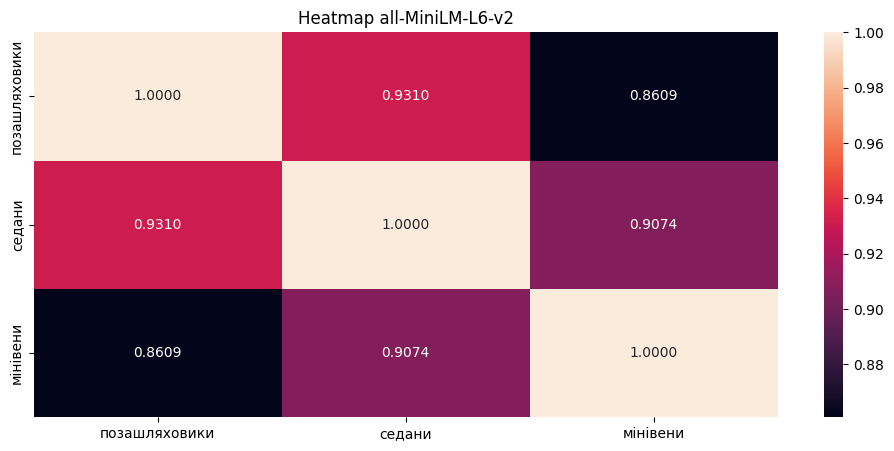

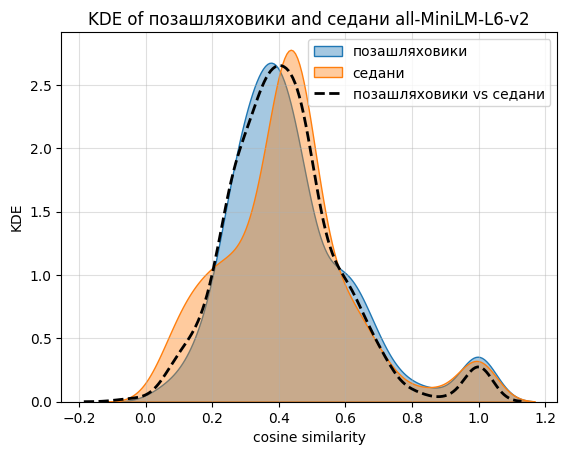

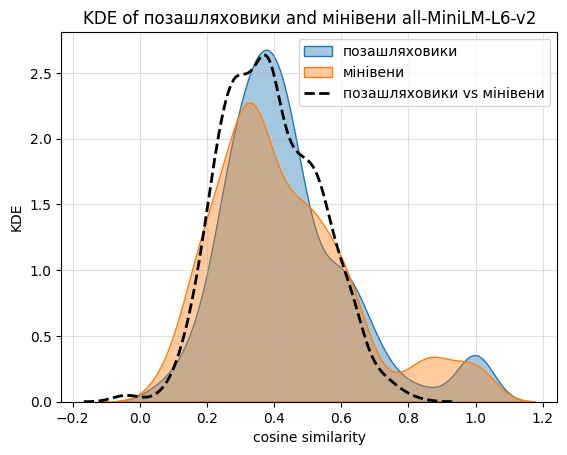

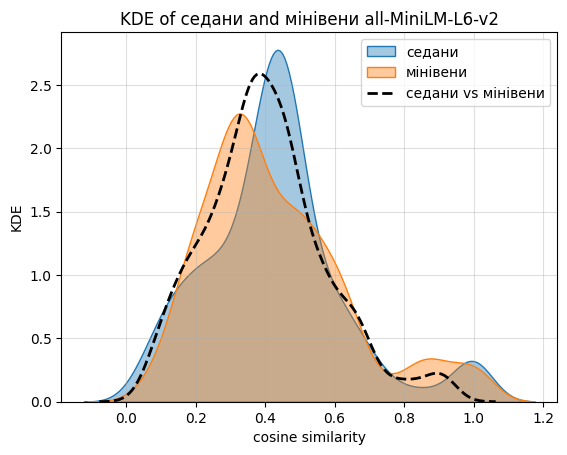


universal-sentence-encoder


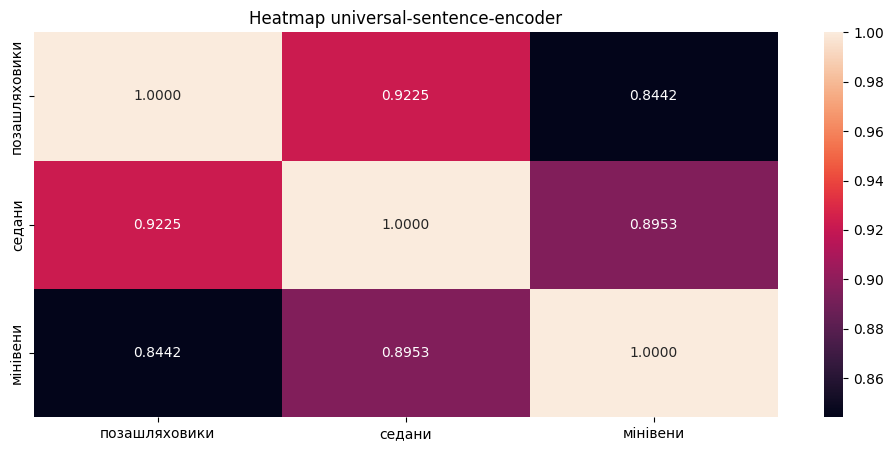

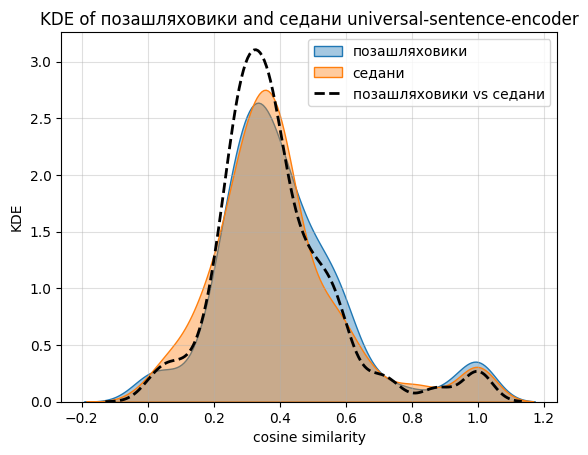

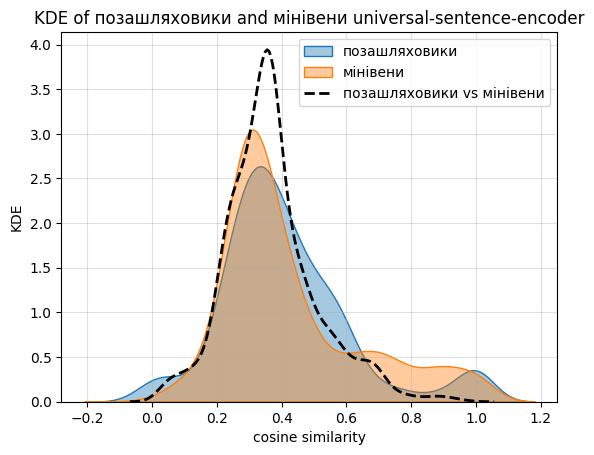

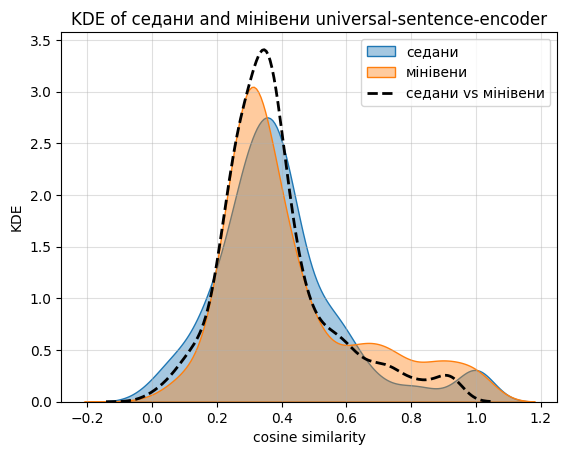


multilingual-e5-base


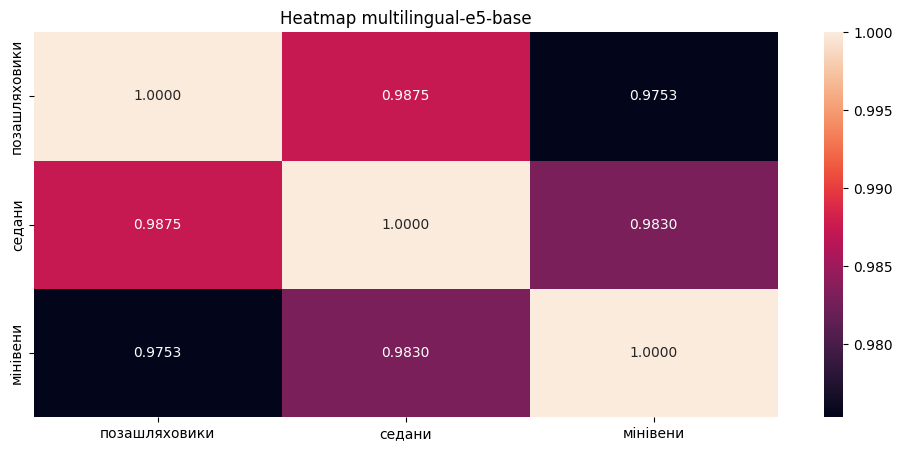

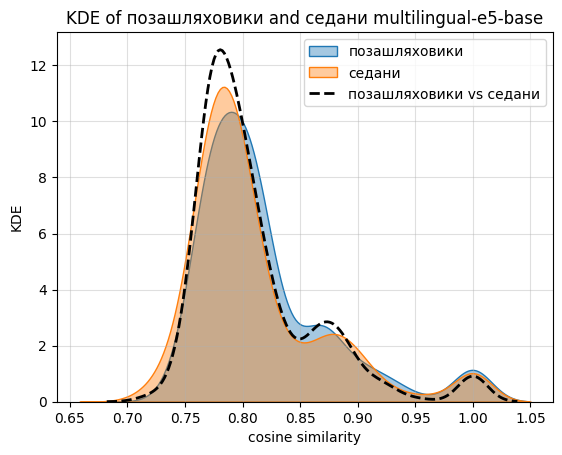

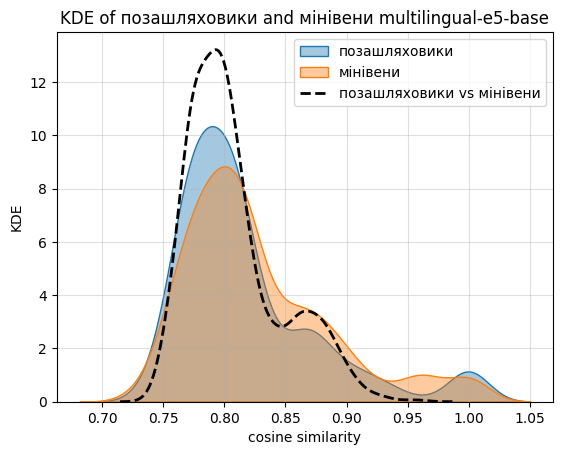

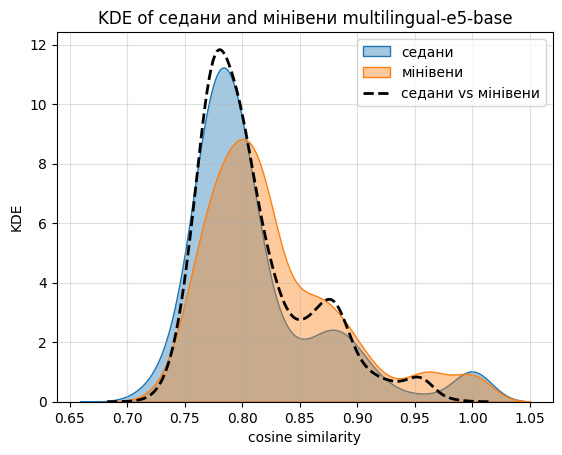

In [104]:
print('SIMILARITY ANALYSIS')
similarity_analysis(car_dict)